In [14]:
# ------------------------------------------------------------------------------
# FASE 1: CONFIGURACIÓN
# ------------------------------------------------------------------------------
# Establecer working directory
import os
working_dir = '/home/nikolai/Dropbox/Trabajos/TESIS MAESTRIA/Paper/'
os.chdir(working_dir)
print(f"Working directory: {os.getcwd()}")

# Librerías esenciales
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import warnings
import zipfile
warnings.filterwarnings('ignore')

Working directory: /home/nikolai/Dropbox/Trabajos/TESIS MAESTRIA/Paper


In [15]:
# ------------------------------------------------------------------------------
# FASE 2: CARGA DE DATOS PRINCIPALES
# ------------------------------------------------------------------------------
ruta_archivo = '/home/nikolai/Dropbox/Trabajos/TESIS MAESTRIA/Paper/Dataset_DISTRITAL.xlsx'
df = pd.read_excel(ruta_archivo, sheet_name='Hoja1')

# ------------------------------------------------------------------------------
# FASE 3: PROCESAMIENTO ESPACIAL (SHAPEFILE) – SOLO PARA OBTENER ÁREA
# ------------------------------------------------------------------------------
# El shapefile ya está descomprimido en esta ruta
extract_path = '/home/nikolai/Dropbox/Trabajos/TESIS MAESTRIA/Paper/mapa_distritos/'

try:
    # Verificar si la carpeta existe
    if not os.path.exists(extract_path):
        print(f"La carpeta {extract_path} no existe")
        df_geo = None
    else:
        # Buscar el archivo .shp dentro de la carpeta
        shp_file = None
        for root, dirs, files in os.walk(extract_path):
            for file in files:
                if file.endswith(".shp"):
                    shp_file = os.path.join(root, file)
                    break
            if shp_file:
                break

        if shp_file:
            print(f"Cargando shapefile: {shp_file}")
            distritos_peru = gpd.read_file(shp_file)

            # Identificar columna de UBIGEO
            col_target = next((c for c in ['UBIGEO', 'IDDIST', 'CODDIST', 'cod_dist', 'ubigeo'] if c in distritos_peru.columns), None)

            if col_target:
                distritos_peru['UBIGEO'] = distritos_peru[col_target].astype(str).str.zfill(6)
                # Reproyectar a métrico para calcular área en km²
                distritos_peru_metric = distritos_peru.to_crs(epsg=3857)
                distritos_peru['AREA'] = distritos_peru_metric.geometry.area / 1_000_000  # m² -> km²
                df_geo = distritos_peru[['UBIGEO', 'AREA']].copy()
                print("Área calculada correctamente.")
                print(f"Shapefile cargado con {len(distritos_peru)} registros")
            else:
                print("No se encontró columna de UBIGEO. Se omite el cálculo de área.")
                print(f"Columnas disponibles: {list(distritos_peru.columns)}")
                df_geo = None
        else:
            print(f"No se encontró archivo .shp en {extract_path}")
            df_geo = None

except Exception as e:
    print(f"Error al procesar shapefile: {e}")
    import traceback
    traceback.print_exc()
    df_geo = None

# Verificar resultado
if df_geo is not None:
    print(f"\n✓ df_geo creado: {df_geo.shape}")
    print(df_geo.head())
else:
    print("\n✗ No se pudo crear df_geo")

# ------------------------------------------------------------------------------
# FASE 4: PREPARACIÓN DEL DATASET DE TRABAJO
# ------------------------------------------------------------------------------
df_trabajo = df.copy()

observaciones_iniciales = len(df_trabajo)
municipalidades_iniciales = df_trabajo['UBIGEO'].nunique()
print(f"\n1. DATASET ORIGINAL (SIN FILTROS):")
print(f"   Total de observaciones (filas):     {observaciones_iniciales:,}")
print(f"   Municipalidades únicas (UBIGEO):    {municipalidades_iniciales:,}")

# Eliminar filas sin datos completos (según tu filtro original)
df_trabajo = df_trabajo[~df_trabajo['DATOS_COMPLETOS'].isin([0])]
df_trabajo['UBIGEO'] = df_trabajo['UBIGEO'].astype(str).str.replace('X', '0', case=False)

observaciones_finales = len(df_trabajo)
municipalidades_finales = df_trabajo['UBIGEO'].nunique()
print(f"\n2. DATASET FINAL (DESPUÉS DEL FILTRO):")
print(f"   Observaciones finales:              {observaciones_finales:,}")
print(f"   Municipalidades finales:            {municipalidades_finales:,}")
print(f"   Observaciones eliminadas:           {observaciones_iniciales - observaciones_finales:,}")
print(f"   % del total original:               {(observaciones_finales/observaciones_iniciales)*100:.2f}%")


# Unir área geográfica si está disponible
if df_geo is not None:
    df_trabajo = pd.merge(df_trabajo, df_geo, on='UBIGEO', how='left')
else:
    df_trabajo['AREA'] = np.nan

# ------------------------------------------------------------------------------
# FASE 5: INGENIERÍA DE CARACTERÍSTICAS
# ------------------------------------------------------------------------------
# Jerarquía política
df_trabajo['JERARQUIA_POLITICA'] = ((df_trabajo.get('AREA_POLITICO_ADMINISTRATIVA', 0) +
                                     df_trabajo.get('ES_PROVINCIAL', 0)) > 0).astype(int)

# Infraestructura deportiva
df_trabajo['INFRA_MAYOR'] = (df_trabajo.get('ESTADIOS', 0).fillna(0) +
                             df_trabajo.get('COMPLEJOS_DEPORTIVOS', 0).fillna(0) +
                             df_trabajo.get('COLISEOS_DEPORTIVOS', 0).fillna(0))

df_trabajo['INFRA_MENOR'] = (df_trabajo.get('LOSAS_MULTIDEPORTIVAS', 0).fillna(0) +
                             df_trabajo.get('LOSAS_FULBITO', 0).fillna(0) +
                             df_trabajo.get('LOSAS_VOLEY', 0).fillna(0) +
                             df_trabajo.get('LOSAS_BASQUET', 0).fillna(0) +
                             df_trabajo.get('PARQUES_ZONALES', 0).fillna(0) +
                             df_trabajo.get('PISCINAS', 0).fillna(0) +
                             df_trabajo.get('GIMNASIOS', 0).fillna(0))

# Profesionales per cápita (por cada 1000 habitantes)
df_trabajo['PROFESIONALES_PC'] = 1000 * (df_trabajo.get('PROFESIONALES', 0).fillna(0) /
                                         df_trabajo.get('POBLACION', np.nan).fillna(1))

# Gobernanza
df_trabajo['TRANSPARENCIA'] = df_trabajo.get('TRANSPARENCIA', 0).fillna(0)
df_trabajo['PARTICIPACION'] = (df_trabajo.get('PARTICIPA_PP', 0).fillna(0) +
                               df_trabajo.get('JUNTA_DELEGADOS_ACTIVIDAD', 0).fillna(0))
df_trabajo['CAPACIDAD_PLAN'] = (df_trabajo.get('PDMC', 0).fillna(0) +
                                df_trabajo.get('PEI', 0).fillna(0))

# Variables fiscales (ya vienen en el dataset, solo nos aseguramos de que existan)
df_trabajo['PROP_PIM_TRANSFERENCIAS_PP0101'] = df_trabajo.get('PROP_PIM_TRANSFERENCIAS_PP0101', np.nan)
df_trabajo['PROP_PP0101_SOBRE_TOTAL_PIM'] = df_trabajo.get('PROP_PP0101_SOBRE_TOTAL_PIM', np.nan)
df_trabajo['NIVEL_EJECUCION_PP0101'] = df_trabajo.get('NIVEL_EJECUCION_PP0101', np.nan)

# Demografía
df_trabajo['POB_VARONES'] = df_trabajo.get('POB_VARONES', np.nan)
df_trabajo['POB_15_64'] = df_trabajo.get('POB_15_64', np.nan)
df_trabajo['POB_URBANA'] = df_trabajo.get('POB_URBANA', np.nan)
df_trabajo['DENSIDAD'] = 1000 * df_trabajo.get('POBLACION', np.nan) / df_trabajo['AREA']

# Variable objetivo
df_trabajo['PROP_GASTO_DEPORTE'] = df_trabajo.get('PROP_GASTO_INFRAESTRUCTURA_DEPORTIVA_Y_RECREATIVA_PP0101', np.nan)

# Lag de la variable objetivo (por distrito)
df_trabajo = df_trabajo.sort_values(by=['UBIGEO', 'AÑO'])
df_trabajo['LAG_PROP_GASTO_DEPORTE'] = df_trabajo.groupby('UBIGEO')['PROP_GASTO_DEPORTE'].shift(1)

len(df_trabajo)

Cargando shapefile: /home/nikolai/Dropbox/Trabajos/TESIS MAESTRIA/Paper/mapa_distritos/DISTRITOS.shp
Área calculada correctamente.
Shapefile cargado con 1874 registros

✓ df_geo creado: (1874, 2)
   UBIGEO         AREA
0  100902  3337.667292
1  100904  1796.403505
2  250305   211.713278
3  250302  1936.246621
4  250304   642.399425

1. DATASET ORIGINAL (SIN FILTROS):
   Total de observaciones (filas):     12,423
   Municipalidades únicas (UBIGEO):    1,840

2. DATASET FINAL (DESPUÉS DEL FILTRO):
   Observaciones finales:              12,321
   Municipalidades finales:            1,834
   Observaciones eliminadas:           102
   % del total original:               99.18%


12321

In [16]:
# ------------------------------------------------------------------------------
# FASE 6: SELECCIÓN DE VARIABLES PARA EL MODELO
# ------------------------------------------------------------------------------
features = [
    'JERARQUIA_POLITICA',
    'INFRA_MAYOR',
    'INFRA_MENOR',
    'PROFESIONALES_PC',
    'TRANSPARENCIA',
    'PARTICIPACION',
    'CAPACIDAD_PLAN',
    'PROP_PIM_TRANSFERENCIAS_PP0101',
    'DENSIDAD',
    'POB_VARONES',
    'POB_15_64',
    'POB_URBANA',
    'LAG_PROP_GASTO_DEPORTE',
    'NIVEL_EJECUCION_PP0101',
    'PROP_PP0101_SOBRE_TOTAL_PIM',
    'CICLO_ELECTORAL'
]

target = 'PROP_GASTO_DEPORTE'

# Conservamos solo columnas necesarias
columnas_utiles = features + [target, 'UBIGEO', 'AÑO']
df_modelo = df_trabajo[columnas_utiles].copy()

# Eliminar filas donde el target sea nulo
df_modelo = df_modelo.dropna(subset=[target])

# ------------------------------------------------------------------------------
# FASE 7: DIVISIÓN CON GROUPKFOLD (EVITA FUGA DE DATOS EN PANEL)
# ------------------------------------------------------------------------------
X = df_modelo[features]
y = df_modelo[target]
groups = df_modelo['UBIGEO']  # Variable de agrupamiento por municipalidad

print(f"Total de observaciones: {len(X)}")
print(f"Total de municipalidades únicas: {groups.nunique()}")

# Imputación con mediana (se ajustará en cada fold para evitar leakage)
imputer = SimpleImputer(strategy='median')

# ------------------------------------------------------------------------------
# FASE 8: OPTIMIZACIÓN DE HIPERPARÁMETROS CON GROUPKFOLD
# ------------------------------------------------------------------------------
from sklearn.model_selection import GroupKFold

# Configurar GroupKFold con 5 folds
gkf = GroupKFold(n_splits=5)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 10, 15],
    'min_samples_split': randint(10, 50),
    'min_samples_leaf': randint(5, 30),
    'max_features': ['sqrt', 'log2', 0.5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    cv=gkf,  # Usar GroupKFold en lugar de cv=5 estándar
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Iniciando búsqueda aleatoria de hiperparámetros con GroupKFold...")
print("Cada fold garantiza que ninguna municipalidad aparezca en train y test simultáneamente")
random_search.fit(X, y, groups=groups)

# ------------------------------------------------------------------------------
# FASE 9: EVALUACIÓN DEL MEJOR MODELO CON VALIDACIÓN CRUZADA
# ------------------------------------------------------------------------------
best_rf = random_search.best_estimator_

# Evaluar mediante validación cruzada con GroupKFold
from sklearn.model_selection import cross_val_score

# Calcular métricas mediante cross-validation
cv_mae = -cross_val_score(best_rf, X, y, groups=groups, cv=gkf, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse = -cross_val_score(best_rf, X, y, groups=groups, cv=gkf, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_r2 = cross_val_score(best_rf, X, y, groups=groups, cv=gkf, scoring='r2', n_jobs=-1)

print("\n--- MEJORES HIPERPARÁMETROS ---")
print(random_search.best_params_)

print("\n--- RENDIMIENTO MEDIO EN VALIDACIÓN CRUZADA (GROUPKFOLD) ---")
print(f"MAE  : {cv_mae.mean():.4f} (±{cv_mae.std():.4f})")
print(f"RMSE : {cv_rmse.mean():.4f} (±{cv_rmse.std():.4f})")
print(f"R²   : {cv_r2.mean():.4f} (±{cv_r2.std():.4f})")

print("\n--- RENDIMIENTO POR FOLD ---")
for i, (mae, rmse, r2) in enumerate(zip(cv_mae, cv_rmse, cv_r2), 1):
    print(f"Fold {i}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# ------------------------------------------------------------------------------
# FASE 10: ENTRENAMIENTO FINAL Y IMPORTANCIA DE VARIABLES
# ------------------------------------------------------------------------------
# Entrenar el modelo final con todos los datos (ya optimizado)
print("\nEntrenando modelo final con todos los datos...")
best_rf.fit(X, y)

# Importancia de variables del modelo final
importancias = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- IMPORTANCIA DE VARIABLES (MODELO FINAL) ---")
print(importancias.to_string())

# Guardar el modelo para uso posterior
import joblib
joblib.dump(best_rf, 'random_forest_groupkfold_final.pkl')
print("\nModelo final guardado como 'random_forest_groupkfold_final.pkl'")

Total de observaciones: 12321
Total de municipalidades únicas: 1834
Iniciando búsqueda aleatoria de hiperparámetros con GroupKFold...
Cada fold garantiza que ninguna municipalidad aparezca en train y test simultáneamente
Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=19, min_samples_split=17, n_estimators=100; total time=   2.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=19, min_samples_split=17, n_estimators=100; total time=   2.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=19, min_samples_split=17, n_estimators=100; total time=   2.1s
[CV] END max_depth=5, max_features=0.5, min_samples_leaf=23, min_samples_split=32, n_estimators=100; total time=   2.0s
[CV] END max_depth=5, max_features=0.5, min_samples_leaf=23, min_samples_split=32, n_estimators=100; total time=   2.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=19, min_samples_split=17, n_estimators=100; total tim

In [ ]:
# ------------------------------------------------------------------------------
# FASE 11: INTERPRETABILIDAD AVANZADA (SHAP, PDP y Permutation Importance)
# Nota: Se utiliza el dataset completo (X, y) y el modelo final (best_rf) 
# entrenado en la Fase 10 para generar las visualizaciones de interpretabilidad.
# ------------------------------------------------------------------------------
import shap
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import matplotlib.pyplot as plt

print("\n=== INICIANDO ANÁLISIS DE INTERPRETABILIDAD (SHAP & PDP) ===")

# 1. VALORES SHAP (SHapley Additive exPlanations)
# Inicializamos el explicador para el Random Forest final
explainer = shap.TreeExplainer(best_rf)

# Muestra representativa para los gráficos de resumen (SHAP puede ser intensivo)
# Se usa una muestra aleatoria de 1500 observaciones para mantener legibilidad
X_sample = X.sample(n=1500, random_state=42) if len(X) > 1500 else X

print("Calculando valores SHAP (esto puede tomar un par de minutos)...")
shap_values = explainer.shap_values(X_sample)

# Gráfico 1: SHAP Summary Plot (Muestra importancia + dirección + no linealidad)
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=features, show=False)
plt.title("SHAP Summary Plot: Impacto de los Predictores sobre la Concentración del Gasto")
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# Gráfico 2: SHAP Bar Plot (La métrica robusta para reemplazar/complementar la MDI)
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=features, plot_type="bar", show=False)
plt.title("Importancia de Variables basada en SHAP (Media del valor absoluto de SHAP)")
plt.xlabel("Impacto medio en la predicción")
plt.tight_layout()
plt.savefig("shap_bar_plot.png", dpi=300, bbox_inches='tight')
plt.show()


# 2. PERMUTATION IMPORTANCE
# Se calcula sobre el dataset completo (X, y) utilizado para ajustar el modelo final.
# Nota: La evaluación de rendimiento se hizo con GroupKFold (para evitar fuga de datos),
# pero la interpretabilidad del modelo final ajustado requiere usar los datos de entrenamiento.
print("Calculando Permutation Importance sobre el modelo final...")
perm_result = permutation_importance(best_rf, X, y, n_repeats=10, random_state=42, n_jobs=-1)

# Ordenamos de mayor a menor
perm_importances = pd.Series(perm_result.importances_mean, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_importances.index[::-1], perm_importances.values[::-1], color='teal')
plt.title("Permutation Feature Importance (Modelo Final Ajustado)")
plt.xlabel("Disminución en R² al permutar la variable")
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=300, bbox_inches='tight')
plt.show()

print("=== ANÁLISIS DE INTERPRETABILIDAD COMPLETADO ===")

In [17]:
# ============================================================
# TABLAS DE PARTIAL DEPENDENCE (PDP)
# Genera una tabla con los valores de PDP para cada variable
# y la exporta a Excel.
# ============================================================

import pandas as pd
from sklearn.inspection import partial_dependence

# Variables para las que se calculará el PDP
top_features_pdp = [
    'NIVEL_EJECUCION_PP0101',
    'DENSIDAD',
    'PROP_PP0101_SOBRE_TOTAL_PIM'
]

# Mantener solo las variables presentes en el modelo
top_features_pdp = [f for f in top_features_pdp if f in features]

print("Generando tablas de Partial Dependence...")
print()

for feature in top_features_pdp:

    print(f"Procesando: {feature}")

    # Calcular el PDP
    pd_result = partial_dependence(
        estimator=best_rf,
        X=X,
        features=[feature],
        kind="average",
        grid_resolution=100
    )

    # Extraer valores
    x_values = pd_result["grid_values"][0]
    pd_values = pd_result["average"][0]

    # Crear tabla
    tabla = pd.DataFrame({
        feature: x_values,
        "Partial_Dependence": pd_values
    })

    # Calcular el cambio absoluto respecto al punto anterior
    tabla["Cambio_Absoluto"] = tabla["Partial_Dependence"].diff()

    # Calcular el cambio porcentual respecto al punto anterior
    tabla["Cambio_Porcentual (%)"] = (
        tabla["Partial_Dependence"].pct_change() * 100
    )

    # Redondear para una mejor presentación
    tabla = tabla.round({
        feature: 6,
        "Partial_Dependence": 6,
        "Cambio_Absoluto": 6,
        "Cambio_Porcentual (%)": 2
    })

    # Mostrar las primeras filas
    print(tabla.head(10))
    print()

    # Guardar la tabla en Excel
    nombre_archivo = f"PDP_{feature}.xlsx"
    tabla.to_excel(nombre_archivo, index=False)

    print(f"Archivo guardado: {nombre_archivo}")
    print("-" * 60)

print()
print("Todas las tablas se generaron correctamente.")

Generando tablas de Partial Dependence...

Procesando: NIVEL_EJECUCION_PP0101
   NIVEL_EJECUCION_PP0101  Partial_Dependence  Cambio_Absoluto  \
0                0.000000            0.329519              NaN   
1                0.010101            0.769235         0.439716   
2                0.020202            0.781805         0.012570   
3                0.030303            0.784219         0.002414   
4                0.040404            0.790692         0.006473   
5                0.050505            0.793312         0.002620   
6                0.060606            0.796705         0.003393   
7                0.070707            0.807058         0.010353   
8                0.080808            0.812369         0.005311   
9                0.090909            0.813051         0.000683   

   Cambio_Porcentual (%)  
0                    NaN  
1                 133.44  
2                   1.63  
3                   0.31  
4                   0.83  
5                   0.33  
6     

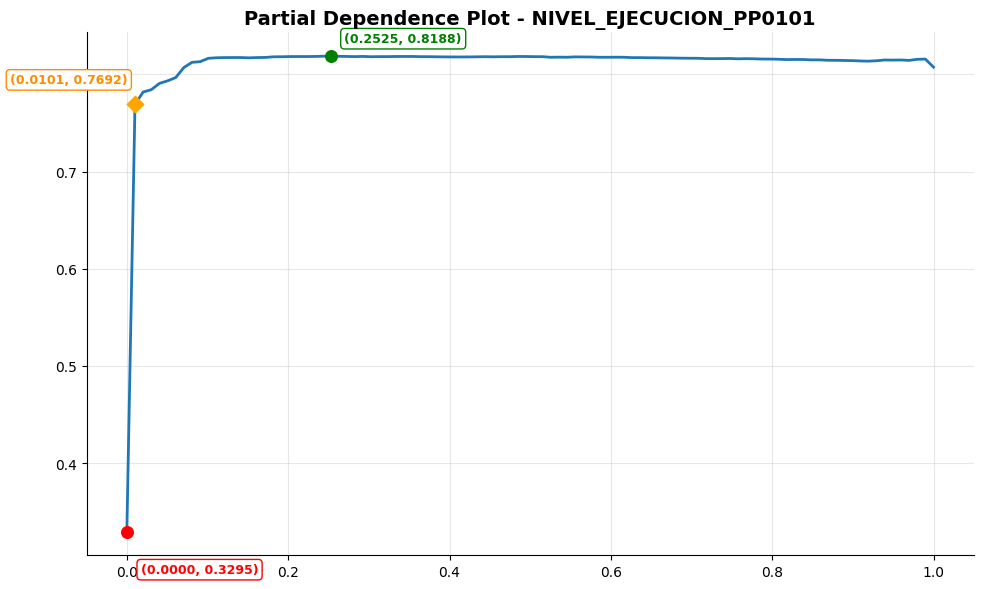

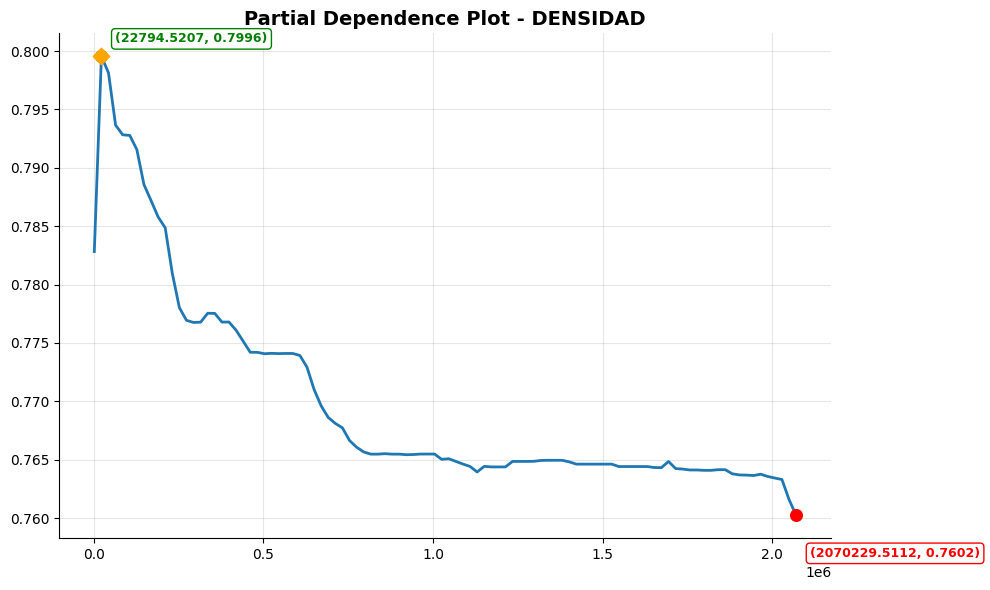

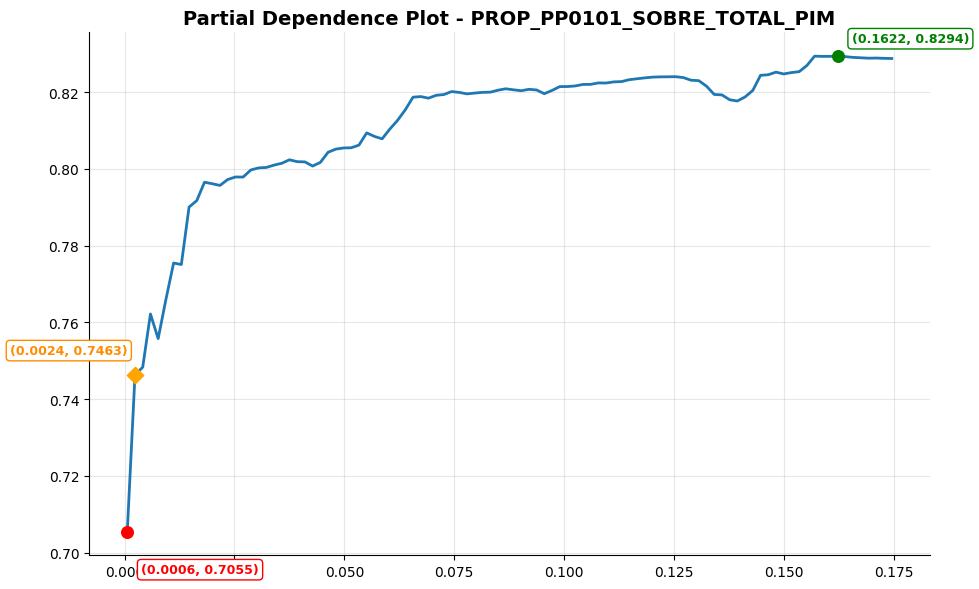

Gráficos generados correctamente.


In [19]:
# ============================================================
# GRÁFICOS DE PARTIAL DEPENDENCE (PDP)
# Etiqueta automáticamente:
#   - El máximo PDP
#   - El mínimo PDP
#   - El mayor cambio porcentual
#
# Ajustes:
#   - La etiqueta solo muestra las coordenadas (X, Y)
#   - Si dos puntos coinciden, solo se etiqueta una vez
#   - Se eliminan las etiquetas de los ejes
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Variables a graficar
top_features_pdp = [
    'NIVEL_EJECUCION_PP0101',
    'DENSIDAD',
    'PROP_PP0101_SOBRE_TOTAL_PIM'
]

for feature in top_features_pdp:

    archivo = f"PDP_{feature}.xlsx"

    # Leer la tabla previamente generada
    tabla = pd.read_excel(archivo)

    # Índices de los puntos notables
    idx_max = tabla["Partial_Dependence"].idxmax()
    idx_min = tabla["Partial_Dependence"].idxmin()
    idx_cambio = tabla["Cambio_Porcentual (%)"].abs().idxmax()

    # Crear figura
    fig, ax = plt.subplots(figsize=(10,6))

    # Curva PDP
    ax.plot(
        tabla[feature],
        tabla["Partial_Dependence"],
        linewidth=2
    )

    # Para evitar etiquetas duplicadas
    puntos_etiquetados = set()

    # Definición de los puntos a destacar
    puntos = [
        (idx_max, "green", "o", (10, 10), "green"),
        (idx_min, "red", "o", (10, -30), "red"),
        (idx_cambio, "orange", "D", (-90, 15), "darkorange")
    ]

    for idx, color, marker, offset, edgecolor in puntos:

        x = tabla.loc[idx, feature]
        y = tabla.loc[idx, "Partial_Dependence"]

        # Dibujar el marcador siempre
        ax.scatter(
            x,
            y,
            color=color,
            marker=marker,
            s=70,
            zorder=5
        )

        # Etiquetar solo si ese punto aún no fue etiquetado
        clave = (round(float(x), 10), round(float(y), 10))

        if clave not in puntos_etiquetados:

            ax.annotate(
                f"({x:.4f}, {y:.4f})",
                xy=(x, y),
                xytext=offset,
                textcoords="offset points",
                fontsize=9,
                fontweight="bold",
                color=edgecolor,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc="white",
                    ec=edgecolor
                )
            )

            puntos_etiquetados.add(clave)

    # Estética
    ax.set_title(
        f"Partial Dependence Plot - {feature}",
        fontsize=14,
        fontweight="bold"
    )

    # Quitar etiquetas de los ejes
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.grid(alpha=0.3)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        f"PDP_{feature}_Anotado.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("Gráficos generados correctamente.")

In [ ]:
# ------------------------------------------------------------------------------
# FASE 12: OPTIMIZACIÓN DE RANDOM FOREST PARA CADA AÑO POR SEPARADO
# ------------------------------------------------------------------------------

# Diccionario para almacenar los subconjuntos
datasets_por_year = {}

# Iterar sobre los años de 2013 a 2024
anos = list(range(2013, 2025))

for ano in anos:
    print(f"--- Procesando Año: {ano} ---")

    # Filtrar el dataset por la variable AÑO
    df_ano = df_trabajo[df_trabajo['AÑO'] == ano].copy()

    if df_ano.empty:
        print(f"No hay datos para el año {ano}.\n")
        continue

    # Guardar el subconjunto en el diccionario
    datasets_por_year[f'year_{ano}'] = df_ano

    print(f"Año {ano}: {len(df_ano)} registros procesados.")

# La lista 'features' original (contiene todas las variables candidatas)
# Vamos a definir una lista base sin CICLO_ELECTORAL, porque es constante dentro de cada año
features_sin_ciclo = [f for f in features if f != 'CICLO_ELECTORAL']

# También definimos la lista para 2013 (sin LAG)
features_2013 = [f for f in features_sin_ciclo if f != 'LAG_PROP_GASTO_DEPORTE']

target = "PROP_GASTO_DEPORTE"

# Diccionarios para almacenar resultados
modelos_anuales = {}
metricas_anuales = {}
importancias_anuales = {}

# Espacio de búsqueda de hiperparámetros (el mismo que usaste para el modelo global)
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 10, 15],
    'min_samples_split': randint(10, 50),
    'min_samples_leaf': randint(5, 30),
    'max_features': ['sqrt', 'log2', 0.5]
}

print("=== OPTIMIZACIÓN DE RANDOM FOREST POR AÑO (CON RANDOMIZED SEARCH) ===\n")

for year_key in sorted(datasets_por_year.keys()):
    año = int(year_key.split('_')[1])
    print(f"--- Procesando Año: {año} ---")

    df_year = datasets_por_year[year_key].copy()

    # Seleccionar las características adecuadas para este año
    if año == 2013:
        features_activas = features_2013.copy()
        print("Año 2013: se excluye LAG_PROP_GASTO_DEPORTE.")
    else:
        features_activas = features_sin_ciclo.copy()

    # Eliminar filas con target nulo
    df_year = df_year.dropna(subset=[target])

    # Verificar que haya suficientes datos
    if len(df_year) < 30:
        print(f"Año {año}: datos insuficientes para entrenar ({len(df_year)} registros). Se omite.\n")
        continue

    X = df_year[features_activas]
    y = df_year[target]

    # Imputación con mediana
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)

    # División entrenamiento / prueba (estratificada solo si hay más de 50 obs)
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=42
    )

    # Configurar el estimador base
    rf = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True)

    # RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=15,                     # 15 combinaciones, balance entre tiempo y exhaustividad
        cv=5,
        scoring='neg_mean_absolute_error',
        verbose=0,                     # Cambiar a 1 o 2 si deseas ver el progreso detallado
        random_state=42,
        n_jobs=-1
    )

    print(f"Entrenando modelo optimizado para {año} ({X_train.shape[0]} obs en train)...")
    random_search.fit(X_train, y_train)

    # Mejor modelo
    best_rf = random_search.best_estimator_

    # Predicciones y métricas en test
    y_pred = best_rf.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    oob = best_rf.oob_score_

    # Guardar resultados
    modelos_anuales[año] = best_rf
    metricas_anuales[año] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'OOB': oob}
    importancias_anuales[año] = pd.Series(
        best_rf.feature_importances_,
        index=features_activas
    ).sort_values(ascending=False)

    # Reporte resumido
    print(f"Resultados {año}:")
    print(f"  Mejores hiperparámetros: {random_search.best_params_}")
    print(f"  MAE (test) : {mae:.4f}")
    print(f"  R²  (test) : {r2:.4f}")
    print(f"  OOB Score  : {oob:.4f}")
    print(f"  Top 3 variables: {', '.join(importancias_anuales[año].head(3).index)}")
    print("-" * 60 + "\n")

# Crear tabla resumen de métricas por año
tabla_metricas = pd.DataFrame(metricas_anuales).T
tabla_metricas.index.name = 'Año'
print(tabla_metricas.round(4))

# Consolidar importancias en un DataFrame
df_importancias = pd.DataFrame(importancias_anuales).T.fillna(0)
df_importancias.index.name = 'Año'

# Seleccionar Top 8 variables globales
top_vars = importancias.head(8).index
df_plot = df_importancias[top_vars]

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    df_plot.T, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues', 
    cbar_kws={'label': 'Importancia'},
    annot_kws={'size': 10, 'fontweight': 'bold'},
    ax=ax
)

# Eliminar la etiqueta del eje horizontal
ax.set_xlabel('')

# Reducir tamaño de letra de las etiquetas del eje vertical (variables)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)

# Reducir tamaño de letra de las etiquetas del eje horizontal (años)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9, rotation=0)

# Mantener el título
ax.set_title('Evolución de la Importancia de Variables (Random Forest Anual)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("heatmap_importancias_anuales.png", dpi=300, bbox_inches='tight')
plt.show()